# Projeto Final - Deep Learning aplicado à Análise de Textos Científicos em Português

Descrição

Este projeto demonstra uma aplicação de Deep Learning para Processamento de Linguagem Natural (NLP) em textos científicos em português, utilizando técnicas modernas de representação semântica, extração de entidades e agrupamento não supervisionado.

O trabalho realiza o carregamento e a limpeza do dataset, aplica spaCy para reconhecimento de entidades nomeadas (NER), utiliza regras customizadas para melhorar a identificação de termos relevantes e emprega modelos baseados em BERTimbau/Transformers para gerar representações vetoriais dos textos.

Após a geração dos embeddings, são aplicadas técnicas de agrupamento com K-Means e DBSCAN, além de métodos de redução de dimensionalidade, como PCA e t-SNE, para visualizar os padrões encontrados. Ao final, o notebook também analisa possíveis confusões de classificação das entidades e exporta os resultados obtidos.

Objetivos

O objetivo deste trabalho é aplicar técnicas modernas de NLP e Deep Learning para analisar um conjunto de textos científicos em português.

Durante o desenvolvimento, são realizadas as seguintes etapas:

Carregamento do dataset;
Limpeza e padronização dos textos;
Diagnóstico inicial dos dados;
Extração de entidades nomeadas com spaCy;
Aplicação de regras customizadas com EntityRuler;
Análise morfológica e sintática dos textos;
Geração de embeddings semânticos com BERTimbau ou TF-IDF;
Agrupamento dos textos e entidades com K-Means;
Análise complementar com DBSCAN;
Visualização dos clusters com PCA e t-SNE;
Análise de possíveis confusões de labels;
Exportação dos resultados finais.

## Gabriel Braga Ledo Luduvico
## RA 22404076

## 1. Ambiente e dependências

In [40]:
import sys
import subprocess
import importlib.util
import warnings
warnings.filterwarnings('ignore')

REQUIRED_PACKAGES = ['pandas', 'numpy', 'sklearn', 'matplotlib', 'seaborn', 'spacy', 'torch', 'transformers']
PIP_NAMES = {'sklearn': 'scikit-learn'}

def package_available(module_name: str) -> bool:
    return importlib.util.find_spec(module_name) is not None

for module_name in REQUIRED_PACKAGES:
    if not package_available(module_name):
        pip_name = PIP_NAMES.get(module_name, module_name)
        try:
            print(f'Instalando pacote ausente: {pip_name}')
            subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pip_name], check=True)
        except Exception as exc:
            print(f'Aviso: não foi possível instalar {pip_name}. Motivo: {exc}')

print('Ambiente preparado.')

Ambiente preparado.


In [41]:
import os
import re
import math
import random
import inspect
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import spacy
from IPython.display import display

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.manifold import TSNE

try:
    import torch
    from transformers import AutoTokenizer, AutoModel
    TRANSFORMERS_OK = True
except Exception as exc:
    print(f'Aviso: BERT/transformers indisponível. Motivo: {exc}')
    TRANSFORMERS_OK = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option('display.max_colwidth', 140)
sns.set_theme(style='whitegrid')

OUTPUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('outputs_nlp')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Python: {sys.version.split()[0]}')
print(f'Diretório de saída: {OUTPUT_DIR.resolve()}')
if TRANSFORMERS_OK:
    print(f'PyTorch: {torch.__version__}')
    print(f'CUDA disponível: {torch.cuda.is_available()}')

Python: 3.12.13
Diretório de saída: /kaggle/working
PyTorch: 2.10.0+cpu
CUDA disponível: False


## 2. Carregamento do dataset

In [42]:
DATASET_CANDIDATES = [
    '/kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv',
    '/kaggle/input/dl-2024/dadosTextosCientificos.tsv',
    './dadosTextosCientificos.tsv',
    '../input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv',
]

SAMPLE_DATA = pd.DataFrame({
    'Título_Público': [
        'Açúcar de frutas como substituto da sacarose',
        'Bioeconomia no Cerrado brasileiro',
        'Sistema IoT para monitoramento industrial',
        'Farofa com castanhas brasileiras e proteína animal',
        'Inteligência artificial aplicada à sustentabilidade',
        'Desenvolvimento de fertilizante organomineral',
        'Aplicativo para rastreabilidade de alimentos',
        'Estudo de compostos antioxidantes do cacau',
        'Gêmeo digital para manufatura avançada',
        'Conservação da Amazônia e cadeias produtivas',
        'Plataforma de dados para energia solar',
        'Produto funcional à base de baru e pequi',
    ],
    'Descricao_pública': [
        'Projeto para produzir frutose em pó e desenvolver bolos com menor teor de sacarose.',
        'Pesquisa sobre biodiversidade, sociobiodiversidade e desenvolvimento sustentável no bioma Cerrado.',
        'Desenvolvimento de sensores IoT, edge computing e análise de dados para a indústria.',
        'Linha de produtos alimentícios com castanha-do-brasil e ingredientes regionais.',
        'Uso de inteligência artificial, machine learning e ODS para inovação sustentável.',
        'Formulação de fertilizantes a partir de resíduos agroindustriais e materiais orgânicos.',
        'Sistema digital para rastrear origem, qualidade e segurança de alimentos.',
        'Avaliação de antioxidantes, polifenóis e valor nutricional em derivados de cacau.',
        'Aplicação de gêmeo digital, manufatura aditiva e manutenção preditiva.',
        'A Amazônia é um bioma estratégico para bioeconomia, conservação e inovação.',
        'Solução baseada em IA para otimização de geração fotovoltaica e BESS.',
        'Desenvolvimento de alimento funcional com frutos nativos do Cerrado, como baru e pequi.',
    ]
})

def read_tsv_robust(path: str) -> pd.DataFrame:
    last_error = None
    for enc in ['latin1', 'cp1252', 'utf-8', 'utf-8-sig']:
        try:
            return pd.read_csv(path, sep='	', encoding=enc)
        except Exception as exc:
            last_error = exc
    raise RuntimeError(f'Falha ao ler {path}. Último erro: {last_error}')

selected_path = next((p for p in DATASET_CANDIDATES if Path(p).exists()), None)

if selected_path:
    df_raw = read_tsv_robust(selected_path)
    dataset_source = selected_path
else:
    df_raw = SAMPLE_DATA.copy()
    dataset_source = 'SAMPLE_DATA interno, usado porque o TSV não foi encontrado'

print(f'Fonte dos dados: {dataset_source}')
print(f'Formato original: {df_raw.shape}')
display(df_raw.head())

Fonte dos dados: SAMPLE_DATA interno, usado porque o TSV não foi encontrado
Formato original: (12, 2)


,Título_Público,Descricao_pública
0,Açúcar de frutas como substituto da sacarose,Projeto para produzir frutose em pó e desenvolver bolos com menor teor de sacarose.
1,Bioeconomia no Cerrado brasileiro,"Pesquisa sobre biodiversidade, sociobiodiversidade e desenvolvimento sustentável no bioma Cerrado."
2,Sistema IoT para monitoramento industrial,"Desenvolvimento de sensores IoT, edge computing e análise de dados para a indústria."
3,Farofa com castanhas brasileiras e proteína animal,Linha de produtos alimentícios com castanha-do-brasil e ingredientes regionais.
4,Inteligência artificial aplicada à sustentabilidade,"Uso de inteligência artificial, machine learning e ODS para inovação sustentável."


## 3. Limpeza textual e padronização de colunas

In [43]:
def normalize_col_name(name: str) -> str:
    name = str(name).strip().replace('\ufeff', '').lower()
    replacements = {
        'á': 'a', 'à': 'a', 'â': 'a', 'ã': 'a', 'é': 'e', 'ê': 'e',
        'í': 'i', 'ó': 'o', 'ô': 'o', 'õ': 'o', 'ú': 'u', 'ç': 'c'
    }
    for src, dst in replacements.items():
        name = name.replace(src, dst)
    return re.sub(r'[^a-z0-9]+', '_', name).strip('_')

def clean_text(value) -> str:
    if not isinstance(value, str):
        return ''
    value = value.replace('\ufffd', ' ')
    value = value.replace('\x96', '-').replace('\x93', '"').replace('\x94', '"')
    value = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', ' ', value)
    value = re.sub(r'\s+', ' ', value).strip()
    return value

df = df_raw.copy()
df.columns = [normalize_col_name(c) for c in df.columns]

possible_title_cols = ['titulo_publico', 'titulo', 'title', 'nome_projeto']
possible_desc_cols = ['descricao_publica', 'descricao', 'description', 'resumo']

title_col = next((c for c in possible_title_cols if c in df.columns), None)
desc_col = next((c for c in possible_desc_cols if c in df.columns), None)

if title_col is None and desc_col is None:
    object_cols = df.select_dtypes(include='object').columns.tolist()
    if len(object_cols) >= 2:
        title_col, desc_col = object_cols[0], object_cols[1]
    elif len(object_cols) == 1:
        title_col, desc_col = None, object_cols[0]
    else:
        raise ValueError('Não foi encontrada coluna textual no dataset.')

df['titulo'] = df[title_col].apply(clean_text) if title_col else ''
df['descricao'] = df[desc_col].apply(clean_text) if desc_col else ''
df['texto_completo'] = (df['titulo'].fillna('') + ' . ' + df['descricao'].fillna('')).apply(clean_text)
df = df[df['texto_completo'].str.len() > 0].drop_duplicates(subset=['texto_completo']).reset_index(drop=True)

print(f'Coluna de título: {title_col}')
print(f'Coluna de descrição: {desc_col}')
print(f'Registros válidos: {len(df)}')
display(df[['titulo', 'descricao', 'texto_completo']].head(10))

Coluna de título: titulo_publico
Coluna de descrição: descricao_publica
Registros válidos: 12


,titulo,descricao,texto_completo
0,Açúcar de frutas como substituto da sacarose,Projeto para produzir frutose em pó e desenvolver bolos com menor teor de sacarose.,Açúcar de frutas como substituto da sacarose . Projeto para produzir frutose em pó e desenvolver bolos com menor teor de sacarose.
1,Bioeconomia no Cerrado brasileiro,"Pesquisa sobre biodiversidade, sociobiodiversidade e desenvolvimento sustentável no bioma Cerrado.","Bioeconomia no Cerrado brasileiro . Pesquisa sobre biodiversidade, sociobiodiversidade e desenvolvimento sustentável no bioma Cerrado."
2,Sistema IoT para monitoramento industrial,"Desenvolvimento de sensores IoT, edge computing e análise de dados para a indústria.","Sistema IoT para monitoramento industrial . Desenvolvimento de sensores IoT, edge computing e análise de dados para a indústria."
3,Farofa com castanhas brasileiras e proteína animal,Linha de produtos alimentícios com castanha-do-brasil e ingredientes regionais.,Farofa com castanhas brasileiras e proteína animal . Linha de produtos alimentícios com castanha-do-brasil e ingredientes regionais.
4,Inteligência artificial aplicada à sustentabilidade,"Uso de inteligência artificial, machine learning e ODS para inovação sustentável.","Inteligência artificial aplicada à sustentabilidade . Uso de inteligência artificial, machine learning e ODS para inovação sustentável."
5,Desenvolvimento de fertilizante organomineral,Formulação de fertilizantes a partir de resíduos agroindustriais e materiais orgânicos.,Desenvolvimento de fertilizante organomineral . Formulação de fertilizantes a partir de resíduos agroindustriais e materiais orgânicos.
6,Aplicativo para rastreabilidade de alimentos,"Sistema digital para rastrear origem, qualidade e segurança de alimentos.","Aplicativo para rastreabilidade de alimentos . Sistema digital para rastrear origem, qualidade e segurança de alimentos."
7,Estudo de compostos antioxidantes do cacau,"Avaliação de antioxidantes, polifenóis e valor nutricional em derivados de cacau.","Estudo de compostos antioxidantes do cacau . Avaliação de antioxidantes, polifenóis e valor nutricional em derivados de cacau."
8,Gêmeo digital para manufatura avançada,"Aplicação de gêmeo digital, manufatura aditiva e manutenção preditiva.","Gêmeo digital para manufatura avançada . Aplicação de gêmeo digital, manufatura aditiva e manutenção preditiva."
9,Conservação da Amazônia e cadeias produtivas,"A Amazônia é um bioma estratégico para bioeconomia, conservação e inovação.","Conservação da Amazônia e cadeias produtivas . A Amazônia é um bioma estratégico para bioeconomia, conservação e inovação."


## 4. Diagnóstico inicial: localização x conceito

In [44]:
LOC_TERMS = ['brasil', 'cerrado', 'pantanal', 'amazonia', 'amazônia', 'mata atlântica', 'caatinga', 'pampa', 'bioma', 'floresta', 'território', 'região']
CONCEPT_TERMS = ['bioeconomia', 'sustentabilidade', 'desenvolvimento sustentável', 'inovação', 'ods', 'inteligência artificial', 'machine learning', 'deep learning', 'internet das coisas', 'iot', 'edge computing', 'gêmeo digital', 'manufatura aditiva']

def count_terms(text: str, terms: list[str]) -> int:
    t = text.lower()
    return sum(1 for term in terms if term in t)

df['loc_score'] = df['texto_completo'].apply(lambda x: count_terms(x, LOC_TERMS))
df['concept_score'] = df['texto_completo'].apply(lambda x: count_terms(x, CONCEPT_TERMS))
df['confusion_flag'] = (df['loc_score'] > 0) & (df['concept_score'] > 0)

print(f'Textos com possível mistura LOC x CONCEITO: {int(df["confusion_flag"].sum())} de {len(df)}')
display(df[['titulo', 'loc_score', 'concept_score', 'confusion_flag']].head(15))

Textos com possível mistura LOC x CONCEITO: 2 de 12


,titulo,loc_score,concept_score,confusion_flag
0,Açúcar de frutas como substituto da sacarose,0,0,False
1,Bioeconomia no Cerrado brasileiro,3,2,True
2,Sistema IoT para monitoramento industrial,0,2,False
3,Farofa com castanhas brasileiras e proteína animal,1,0,False
4,Inteligência artificial aplicada à sustentabilidade,0,5,False
5,Desenvolvimento de fertilizante organomineral,0,0,False
6,Aplicativo para rastreabilidade de alimentos,0,0,False
7,Estudo de compostos antioxidantes do cacau,0,0,False
8,Gêmeo digital para manufatura avançada,0,2,False
9,Conservação da Amazônia e cadeias produtivas,2,2,True


## 5. spaCy, NER e EntityRuler

In [45]:
def try_download_spacy_model(model_name: str) -> bool:
    try:
        subprocess.run([sys.executable, '-m', 'spacy', 'download', model_name], check=True)
        return True
    except Exception as exc:
        print(f'Aviso: download de {model_name} falhou. Motivo: {exc}')
        return False

def load_spacy_pt():
    candidates = ['pt_core_news_lg', 'pt_core_news_sm']
    for model_name in candidates:
        try:
            return spacy.load(model_name), model_name
        except Exception:
            pass
    for model_name in candidates:
        if try_download_spacy_model(model_name):
            try:
                return spacy.load(model_name), model_name
            except Exception:
                pass
    nlp_blank = spacy.blank('pt')
    if 'sentencizer' not in nlp_blank.pipe_names:
        nlp_blank.add_pipe('sentencizer')
    return nlp_blank, 'spacy.blank("pt")'

nlp, SPACY_MODEL_USED = load_spacy_pt()
if 'sentencizer' not in nlp.pipe_names and 'parser' not in nlp.pipe_names:
    nlp.add_pipe('sentencizer')

print(f'Modelo spaCy usado: {SPACY_MODEL_USED}')
print(f'Pipeline inicial: {nlp.pipe_names}')

Modelo spaCy usado: pt_core_news_lg
Pipeline inicial: ['tok2vec', 'morphologizer', 'parser', 'lemmatizer', 'attribute_ruler', 'ner']


In [46]:
CUSTOM_PATTERNS = [
    {'label': 'ORG', 'pattern': 'ONU'},
    {'label': 'ORG', 'pattern': 'Organização das Nações Unidas'},
    {'label': 'ORG', 'pattern': 'EMBRAPII'},
    {'label': 'ORG', 'pattern': 'HUAWEI'},
    {'label': 'ORG', 'pattern': 'Siemens-Energy'},
    {'label': 'LOC', 'pattern': 'Brasil'},
    {'label': 'LOC', 'pattern': 'Mato Grosso'},
    {'label': 'BIOMA', 'pattern': 'Cerrado'},
    {'label': 'BIOMA', 'pattern': 'Pantanal'},
    {'label': 'BIOMA', 'pattern': 'Amazônia'},
    {'label': 'BIOMA', 'pattern': 'Mata Atlântica'},
    {'label': 'BIOMA', 'pattern': 'Caatinga'},
    {'label': 'BIOMA', 'pattern': 'Pampa'},
    {'label': 'CONCEITO', 'pattern': 'ODS'},
    {'label': 'CONCEITO', 'pattern': 'bioeconomia'},
    {'label': 'CONCEITO', 'pattern': 'desenvolvimento sustentável'},
    {'label': 'CONCEITO', 'pattern': 'sustentabilidade'},
    {'label': 'CONCEITO', 'pattern': 'inteligência artificial'},
    {'label': 'CONCEITO', 'pattern': 'machine learning'},
    {'label': 'CONCEITO', 'pattern': 'deep learning'},
    {'label': 'TECNOLOGIA', 'pattern': 'IoT'},
    {'label': 'TECNOLOGIA', 'pattern': 'edge computing'},
    {'label': 'TECNOLOGIA', 'pattern': 'gêmeo digital'},
    {'label': 'TECNOLOGIA', 'pattern': 'manufatura aditiva'},
    {'label': 'PRODUTO', 'pattern': 'frutose'},
    {'label': 'PRODUTO', 'pattern': 'sacarose'},
    {'label': 'PRODUTO', 'pattern': 'cacau'},
    {'label': 'PRODUTO', 'pattern': 'baru'},
    {'label': 'PRODUTO', 'pattern': 'pequi'},
    {'label': 'PRODUTO', 'pattern': 'castanha-do-brasil'},
    {'label': 'MATERIAL', 'pattern': 'fertilizante organomineral'},
    {'label': 'MATERIAL', 'pattern': 'resíduos agroindustriais'},
]

if 'entity_ruler' not in nlp.pipe_names:
    before = 'ner' if 'ner' in nlp.pipe_names else None
    ruler = nlp.add_pipe('entity_ruler', before=before, config={'overwrite_ents': True})
else:
    ruler = nlp.get_pipe('entity_ruler')

ruler.add_patterns(CUSTOM_PATTERNS)
print(f'Pipeline final: {nlp.pipe_names}')
print(f'Padrões customizados: {len(CUSTOM_PATTERNS)}')

Pipeline final: ['tok2vec', 'morphologizer', 'parser', 'lemmatizer', 'attribute_ruler', 'entity_ruler', 'ner']
Padrões customizados: 32


## 6. Processamento em lote e extração de entidades

In [47]:
texts = df['texto_completo'].tolist()
docs = list(nlp.pipe(texts, batch_size=64))
print(f'Documentos processados: {len(docs)}')

Documentos processados: 12


In [48]:
BAD_CHARS = re.compile(r'[\ufffd\x00-\x1f]')
LABEL_CORRECTIONS = {'Brasil': 'LOC', 'Cerrado': 'BIOMA', 'Pantanal': 'BIOMA', 'Amazônia': 'BIOMA', 'Mata Atlântica': 'BIOMA', 'Caatinga': 'BIOMA', 'Pampa': 'BIOMA', 'ODS': 'CONCEITO', 'ONU': 'ORG'}
CONCEPT_KEYWORDS = ['bioeconomia', 'sustentabilidade', 'desenvolvimento sustentável', 'machine learning', 'deep learning', 'inteligência artificial', 'internet das coisas', 'gêmeo digital', 'edge computing', 'manufatura aditiva']
PRODUCT_KEYWORDS = ['frutose', 'sacarose', 'cacau', 'baru', 'pequi', 'castanha', 'alimento', 'produto']
BIOME_KEYWORDS = ['cerrado', 'pantanal', 'amazônia', 'mata atlântica', 'caatinga', 'pampa']
ORG_STARTS = ('Universidade', 'Instituto', 'Fundação', 'Centro', 'Empresa', 'Laboratório', 'HUAWEI', 'EMBRAPII')

def filter_entity(ent) -> bool:
    txt = ent.text.strip()
    if not txt or BAD_CHARS.search(txt):
        return False
    if len(txt) < 2:
        return False
    if re.fullmatch(r'[\W\d_]+', txt):
        return False
    if re.search(r'\b(de|da|do|das|dos|e)$', txt.lower()):
        return False
    if getattr(ent.root, 'pos_', '') == 'VERB':
        return False
    return True

def correct_label(ent_text: str, original_label: str) -> str:
    txt = ent_text.strip()
    low = txt.lower()
    if txt in LABEL_CORRECTIONS:
        return LABEL_CORRECTIONS[txt]
    if any(k in low for k in BIOME_KEYWORDS):
        return 'BIOMA'
    if any(k in low for k in CONCEPT_KEYWORDS):
        return 'CONCEITO'
    if any(k in low for k in PRODUCT_KEYWORDS):
        return 'PRODUTO'
    if txt.startswith(ORG_STARTS):
        return 'ORG'
    return original_label or 'MISC'

records = []
for doc_idx, doc in enumerate(docs):
    for sent in doc.sents:
        sent_start = sent.start
        for ent in doc.ents:
            if not (sent.start <= ent.start < ent.end <= sent.end):
                continue
            if not filter_entity(ent):
                continue
            txt = clean_text(ent.text)
            label = correct_label(txt, ent.label_)
            root = ent.root
            records.append({
                'doc_idx': doc_idx,
                'titulo': df.loc[doc_idx, 'titulo'],
                'entidade': txt,
                'label_original': ent.label_,
                'label': label,
                'sentenca': clean_text(sent.text),
                'dep_root': getattr(root, 'dep_', '') or 'NA',
                'pos_root': getattr(root, 'pos_', '') or 'NA',
                'head_text': clean_text(getattr(root.head, 'text', '')) if hasattr(root, 'head') else '',
                'n_chars': len(txt),
                'n_tokens': len(ent),
                'pos_token': int(ent.start - sent_start),
            })

ner_dep_df = pd.DataFrame(records)

if ner_dep_df.empty:
    fallback_terms = sorted({p['pattern'] for p in CUSTOM_PATTERNS if isinstance(p.get('pattern'), str)})
    fallback_records = []
    for doc_idx, text in enumerate(texts):
        low = text.lower()
        for term in fallback_terms:
            if term.lower() in low:
                label = next((p['label'] for p in CUSTOM_PATTERNS if p.get('pattern') == term), 'MISC')
                fallback_records.append({
                    'doc_idx': doc_idx,
                    'titulo': df.loc[doc_idx, 'titulo'],
                    'entidade': term,
                    'label_original': label,
                    'label': label,
                    'sentenca': text[:300],
                    'dep_root': 'NA',
                    'pos_root': 'NA',
                    'head_text': '',
                    'n_chars': len(term),
                    'n_tokens': len(term.split()),
                    'pos_token': 0,
                })
    ner_dep_df = pd.DataFrame(fallback_records)

print(f'Registros NER + DEP: {len(ner_dep_df)}')
if not ner_dep_df.empty:
    print(f'Labels encontrados: {sorted(ner_dep_df["label"].unique())}')
    display(ner_dep_df.head(20))
else:
    print('Nenhuma entidade encontrada.')

Registros NER + DEP: 29
Labels encontrados: ['BIOMA', 'CONCEITO', 'MATERIAL', 'MISC', 'ORG', 'PRODUTO', 'TECNOLOGIA']


,doc_idx,titulo,entidade,label_original,label,sentenca,dep_root,pos_root,head_text,n_chars,n_tokens,pos_token
0,0,Açúcar de frutas como substituto da sacarose,sacarose,PRODUTO,PRODUTO,Açúcar de frutas como substituto da sacarose .,nmod,NOUN,substituto,8,1,6
1,0,Açúcar de frutas como substituto da sacarose,frutose,PRODUTO,PRODUTO,Projeto para produzir frutose em pó e desenvolver bolos com menor teor de sacarose.,obj,NOUN,produzir,7,1,3
2,0,Açúcar de frutas como substituto da sacarose,sacarose,PRODUTO,PRODUTO,Projeto para produzir frutose em pó e desenvolver bolos com menor teor de sacarose.,nmod,NOUN,teor,8,1,13
3,1,Bioeconomia no Cerrado brasileiro,Cerrado,BIOMA,BIOMA,Bioeconomia no Cerrado brasileiro .,nmod,NOUN,Bioeconomia,7,1,2
4,1,Bioeconomia no Cerrado brasileiro,desenvolvimento sustentável,CONCEITO,CONCEITO,"Pesquisa sobre biodiversidade, sociobiodiversidade e desenvolvimento sustentável no bioma Cerrado.",conj,NOUN,biodiversidade,27,2,6
5,2,Sistema IoT para monitoramento industrial,IoT,TECNOLOGIA,TECNOLOGIA,Sistema IoT para monitoramento industrial .,flat:name,PROPN,Sistema,3,1,1
6,2,Sistema IoT para monitoramento industrial,IoT,TECNOLOGIA,TECNOLOGIA,"Desenvolvimento de sensores IoT, edge computing e análise de dados para a indústria.",amod,NUM,sensores,3,1,3
7,2,Sistema IoT para monitoramento industrial,edge computing,TECNOLOGIA,CONCEITO,"Desenvolvimento de sensores IoT, edge computing e análise de dados para a indústria.",appos,X,Desenvolvimento,14,2,5
8,3,Farofa com castanhas brasileiras e proteína animal,castanha-do-brasil,PRODUTO,PRODUTO,Linha de produtos alimentícios com castanha-do-brasil e ingredientes regionais.,nmod,NOUN,produtos,18,1,5
9,4,Inteligência artificial aplicada à sustentabilidade,sustentabilidade,CONCEITO,CONCEITO,Inteligência artificial aplicada à sustentabilidade .,obj,NOUN,aplicada,16,1,4


## 7. POS tagging, dependências sintáticas e distribuição de entidades

,POS,frequencia
0,NOUN,85
1,ADP,46
2,PUNCT,32
3,ADJ,29
4,CCONJ,15
5,PROPN,8
6,VERB,7
7,X,4
8,DET,3
9,SCONJ,2


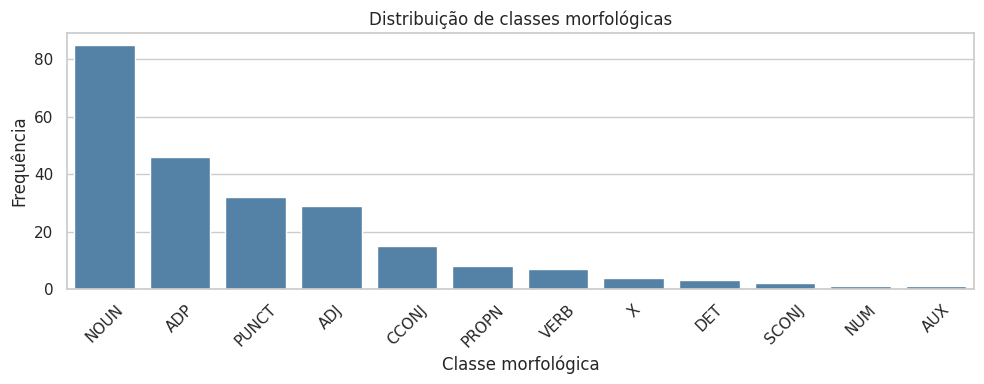

In [49]:
pos_counts = Counter(token.pos_ or 'NA' for doc in docs for token in doc if not token.is_space)
pos_df = pd.DataFrame(pos_counts.most_common(15), columns=['POS', 'frequencia'])
display(pos_df)

if not pos_df.empty:
    plt.figure(figsize=(10, 4))
    ax = sns.barplot(data=pos_df, x='POS', y='frequencia', color='steelblue')
    ax.set_title('Distribuição de classes morfológicas')
    ax.set_xlabel('Classe morfológica')
    ax.set_ylabel('Frequência')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'pos_tags.png', dpi=160)
    plt.show()

,dependencia,frequencia
0,case,45
1,nmod,42
2,punct,32
3,amod,31
4,ROOT,24
5,conj,21
6,cc,15
7,acl,5
8,obj,4
9,det,3


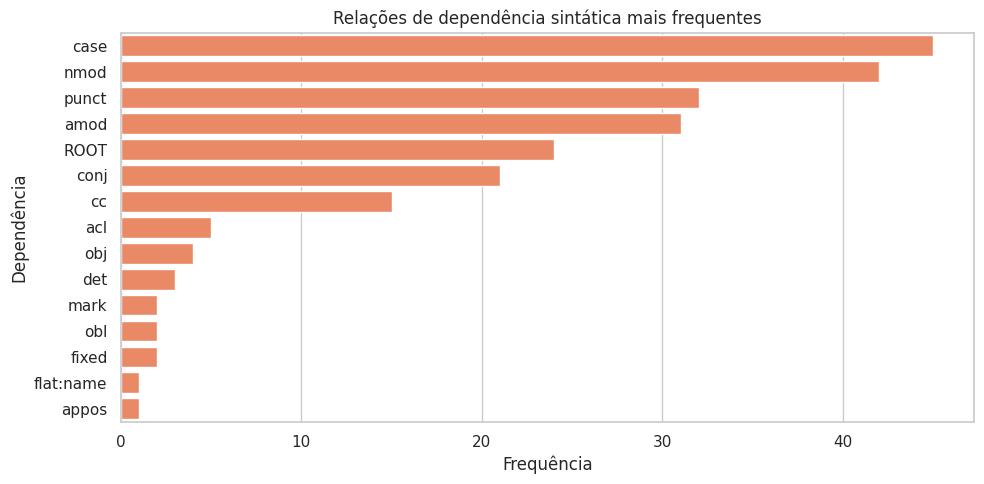

In [50]:
dep_counts = Counter(token.dep_ or 'NA' for doc in docs for token in doc if not token.is_space)
dep_df = pd.DataFrame(dep_counts.most_common(15), columns=['dependencia', 'frequencia'])
display(dep_df)

if not dep_df.empty:
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=dep_df, y='dependencia', x='frequencia', color='coral')
    ax.set_title('Relações de dependência sintática mais frequentes')
    ax.set_xlabel('Frequência')
    ax.set_ylabel('Dependência')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'dependencias_sintaticas.png', dpi=160)
    plt.show()

,label,frequencia
0,PRODUTO,10
1,CONCEITO,9
2,BIOMA,4
3,TECNOLOGIA,2
4,MATERIAL,2
5,MISC,1
6,ORG,1


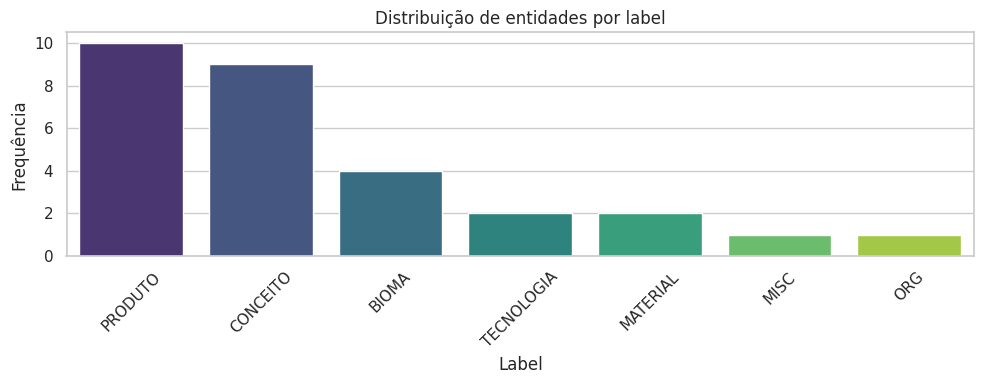

BIOMA: ['Cerrado', 'Amazônia']
CONCEITO: ['desenvolvimento sustentável', 'edge computing', 'sustentabilidade', 'inteligência artificial', 'machine learning', 'ODS', 'gêmeo digital', 'manufatura aditiva', 'bioeconomia']
MATERIAL: ['fertilizante organomineral', 'resíduos agroindustriais']
MISC: ['Plataforma de dados']
ORG: ['BESS']
PRODUTO: ['sacarose', 'frutose', 'castanha-do-brasil', 'cacau', 'baru', 'pequi']
TECNOLOGIA: ['IoT']


In [51]:
if not ner_dep_df.empty:
    label_counts = ner_dep_df['label'].value_counts().reset_index()
    label_counts.columns = ['label', 'frequencia']
    display(label_counts)

    plt.figure(figsize=(10, 4))
    ax = sns.barplot(data=label_counts, x='label', y='frequencia', palette='viridis')
    ax.set_title('Distribuição de entidades por label')
    ax.set_xlabel('Label')
    ax.set_ylabel('Frequência')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'labels_ner.png', dpi=160)
    plt.show()

    for label in sorted(ner_dep_df['label'].unique()):
        examples = ner_dep_df.loc[ner_dep_df['label'] == label, 'entidade'].drop_duplicates().head(12).tolist()
        print(f'{label}: {examples}')
else:
    print('Sem entidades para analisar.')

## 8. Consolidação das entidades únicas

In [52]:
if ner_dep_df.empty:
    unique_ents = pd.DataFrame(columns=['entidade', 'label', 'label_original', 'doc_freq', 'n_chars', 'n_tokens', 'pos_token', 'dep_root', 'pos_root', 'head_text', 'sentenca', 'freq'])
else:
    unique_ents = (
        ner_dep_df.groupby('entidade', as_index=False)
        .agg(
            label=('label', lambda x: x.value_counts().index[0]),
            label_original=('label_original', lambda x: x.value_counts().index[0]),
            doc_freq=('doc_idx', pd.Series.nunique),
            n_chars=('n_chars', 'median'),
            n_tokens=('n_tokens', 'median'),
            pos_token=('pos_token', 'median'),
            dep_root=('dep_root', lambda x: x.value_counts().index[0]),
            pos_root=('pos_root', lambda x: x.value_counts().index[0]),
            head_text=('head_text', lambda x: x.value_counts().index[0] if len(x) else ''),
            sentenca=('sentenca', 'first'),
        )
    )
    freq = ner_dep_df['entidade'].value_counts().rename_axis('entidade').reset_index(name='freq')
    unique_ents = unique_ents.merge(freq, on='entidade', how='left')
    unique_ents = unique_ents.sort_values(['freq', 'doc_freq', 'entidade'], ascending=[False, False, True]).reset_index(drop=True)

print(f'Entidades únicas: {len(unique_ents)}')
display(unique_ents.head(25))

Entidades únicas: 22


,entidade,label,label_original,doc_freq,n_chars,n_tokens,pos_token,dep_root,pos_root,head_text,sentenca,freq
0,Cerrado,BIOMA,BIOMA,2,7.0,1.0,5.0,nmod,NOUN,Bioeconomia,Bioeconomia no Cerrado brasileiro .,2
1,Amazônia,BIOMA,BIOMA,1,8.0,1.0,1.5,nmod,PROPN,Conservação,Conservação da Amazônia e cadeias produtivas .,2
2,IoT,TECNOLOGIA,TECNOLOGIA,1,3.0,1.0,2.0,flat:name,PROPN,Sistema,Sistema IoT para monitoramento industrial .,2
3,baru,PRODUTO,PRODUTO,1,4.0,1.0,8.0,nmod,NOUN,base,Produto funcional à base de baru e pequi .,2
4,cacau,PRODUTO,PRODUTO,1,5.0,1.0,8.0,nmod,NOUN,compostos,Estudo de compostos antioxidantes do cacau .,2
5,pequi,PRODUTO,PRODUTO,1,5.0,1.0,10.0,conj,NOUN,baru,Produto funcional à base de baru e pequi .,2
6,sacarose,PRODUTO,PRODUTO,1,8.0,1.0,9.5,nmod,NOUN,substituto,Açúcar de frutas como substituto da sacarose .,2
7,BESS,ORG,ORG,1,4.0,1.0,10.0,conj,PROPN,geração,Solução baseada em IA para otimização de geração fotovoltaica e BESS.,1
8,ODS,CONCEITO,CONCEITO,1,3.0,1.0,8.0,conj,PROPN,Uso,"Uso de inteligência artificial, machine learning e ODS para inovação sustentável.",1
9,Plataforma de dados,MISC,MISC,1,19.0,3.0,0.0,ROOT,NOUN,Plataforma,Plataforma de dados para energia solar .,1


## 9. Vetorização robusta

Usa vetores do spaCy quando disponíveis; caso contrário, usa TF-IDF com SVD. Em seguida, concatena metadados numéricos normalizados.

In [53]:
def build_text_features(texts_for_features: list[str], nlp_model) -> tuple[np.ndarray, str]:
    if len(texts_for_features) == 0:
        return np.zeros((0, 1)), 'empty'

    vectors = []
    has_useful_vector = False
    for txt in texts_for_features:
        vec = nlp_model(txt).vector
        if vec is not None and len(vec) > 0 and np.isfinite(vec).all() and np.linalg.norm(vec) > 0:
            has_useful_vector = True
        vectors.append(vec if vec is not None and len(vec) > 0 else np.zeros(1))

    if has_useful_vector and len({len(v) for v in vectors}) == 1:
        return np.vstack(vectors).astype(float), 'spacy_vectors'

    max_features = min(2000, max(20, len(texts_for_features) * 5))
    tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=max_features)
    X_tfidf = tfidf.fit_transform(texts_for_features)

    if min(X_tfidf.shape) > 2:
        n_comp = min(100, X_tfidf.shape[0] - 1, X_tfidf.shape[1] - 1)
        if n_comp >= 2:
            svd = TruncatedSVD(n_components=n_comp, random_state=SEED)
            return svd.fit_transform(X_tfidf), 'tfidf_char_svd'

    return X_tfidf.toarray(), 'tfidf_char'

if unique_ents.empty:
    X = np.zeros((0, 1))
    feature_source = 'empty'
else:
    entity_texts = unique_ents['entidade'].astype(str).tolist()
    X_text, feature_source = build_text_features(entity_texts, nlp)
    numeric_cols = ['freq', 'doc_freq', 'n_chars', 'n_tokens', 'pos_token']
    X_num = unique_ents[numeric_cols].fillna(0).astype(float).values
    X_num = StandardScaler().fit_transform(X_num)
    X = np.hstack([X_text, X_num])
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f'Fonte dos vetores: {feature_source}')
print(f'Shape da matriz X: {X.shape}')

Fonte dos vetores: spacy_vectors
Shape da matriz X: (22, 305)


## 10. PCA e escolha automática de K

PCA: 15 componentes explicam até 95.8% da variância.


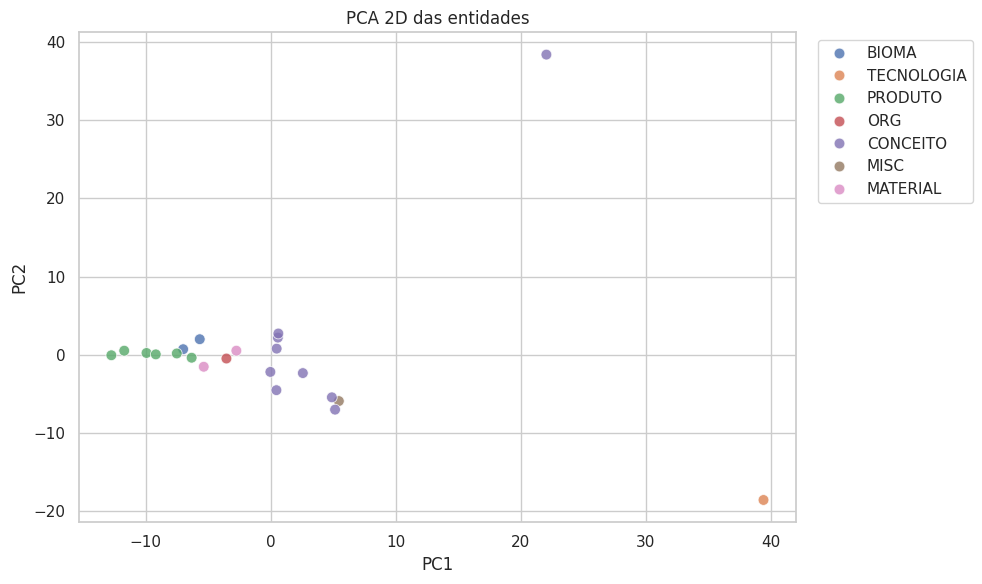

In [54]:
def safe_pca(X_input: np.ndarray, n_components: int = 2) -> np.ndarray:
    if X_input.shape[0] == 0:
        return np.zeros((0, n_components))
    if X_input.shape[0] == 1:
        return np.zeros((1, n_components))
    comp = min(n_components, X_input.shape[0], X_input.shape[1])
    Z = PCA(n_components=comp, random_state=SEED).fit_transform(X_input)
    if comp < n_components:
        Z = np.hstack([Z, np.zeros((Z.shape[0], n_components - comp))])
    return Z

if X.shape[0] >= 2:
    pca_full_components = min(50, X.shape[0] - 1, X.shape[1])
    pca_full = PCA(n_components=pca_full_components, random_state=SEED)
    X_pca_full = pca_full.fit_transform(X)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    n95 = int(np.searchsorted(cumvar, 0.95) + 1) if len(cumvar) else 1
    n95 = min(max(n95, 2), X_pca_full.shape[1])
    X_reduced = X_pca_full[:, :n95]
    print(f'PCA: {n95} componentes explicam até {cumvar[n95-1]:.1%} da variância.')
else:
    X_reduced = X.copy()
    print('Base pequena: PCA ignorado.')

Z_pca_2d = safe_pca(X, 2)

if len(unique_ents) > 0:
    plot_pca = unique_ents.copy()
    plot_pca['pca_x'] = Z_pca_2d[:, 0]
    plot_pca['pca_y'] = Z_pca_2d[:, 1]
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=plot_pca, x='pca_x', y='pca_y', hue='label', s=60, alpha=0.8)
    plt.title('PCA 2D das entidades')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'pca_entidades.png', dpi=160)
    plt.show()
else:
    print('Sem entidades para PCA.')

K escolhido: 2


,k,silhouette
0,2,0.453183
1,3,0.449375
2,4,0.122383
3,5,0.105664
4,6,0.162346
5,7,0.169831
6,8,0.123450
7,9,0.162307
8,10,0.147961


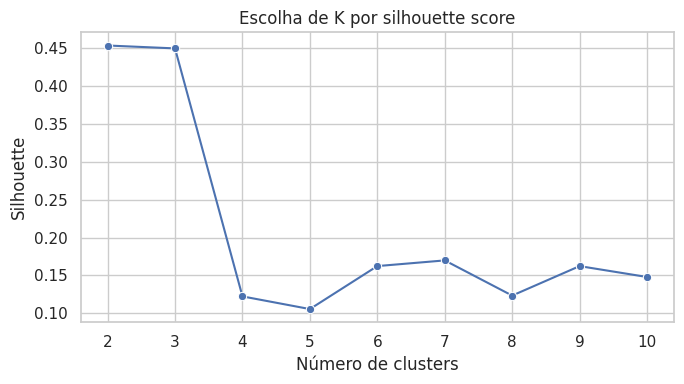

In [55]:
def choose_k_by_silhouette(X_input: np.ndarray, max_k: int = 10) -> tuple[int, pd.DataFrame]:
    n = X_input.shape[0]
    if n < 3:
        return 1, pd.DataFrame(columns=['k', 'silhouette'])
    max_k = min(max_k, n - 1)
    rows = []
    best_k = 2
    best_score = -1
    for k in range(2, max_k + 1):
        try:
            labels = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit_predict(X_input)
            if len(set(labels)) < 2:
                continue
            score = silhouette_score(X_input, labels)
            rows.append({'k': k, 'silhouette': score})
            if score > best_score:
                best_k = k
                best_score = score
        except Exception as exc:
            rows.append({'k': k, 'silhouette': np.nan})
            print(f'Aviso: K={k} falhou. Motivo: {exc}')
    return best_k, pd.DataFrame(rows)

K_FINAL, k_scores = choose_k_by_silhouette(X_reduced, max_k=10)
print(f'K escolhido: {K_FINAL}')
if not k_scores.empty:
    display(k_scores)
    plt.figure(figsize=(7, 4))
    sns.lineplot(data=k_scores, x='k', y='silhouette', marker='o')
    plt.title('Escolha de K por silhouette score')
    plt.xlabel('Número de clusters')
    plt.ylabel('Silhouette')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'silhouette_kmeans.png', dpi=160)
    plt.show()

## 11. KMeans e DBSCAN

In [56]:
if unique_ents.empty:
    unique_ents['cluster_kmeans'] = []
elif K_FINAL <= 1:
    unique_ents['cluster_kmeans'] = 0
else:
    kmeans = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10)
    unique_ents['cluster_kmeans'] = kmeans.fit_predict(X_reduced)

print('Distribuição KMeans:')
if 'cluster_kmeans' in unique_ents.columns and len(unique_ents) > 0:
    display(unique_ents['cluster_kmeans'].value_counts().sort_index().rename_axis('cluster').reset_index(name='quantidade'))

if len(unique_ents) > 0:
    for cluster_id in sorted(unique_ents['cluster_kmeans'].unique()):
        sub = unique_ents[unique_ents['cluster_kmeans'] == cluster_id]
        label_dist = sub['label'].value_counts().to_dict()
        examples = sub['entidade'].head(10).tolist()
        print(f'Cluster {cluster_id} | total={len(sub)} | labels={label_dist}')
        print('  ' + ', '.join(examples))

Distribuição KMeans:


,cluster,quantidade
0,0,21
1,1,1


Cluster 0 | total=21 | labels={'CONCEITO': 9, 'PRODUTO': 6, 'BIOMA': 2, 'MATERIAL': 2, 'ORG': 1, 'MISC': 1}
  Cerrado, Amazônia, baru, cacau, pequi, sacarose, BESS, ODS, Plataforma de dados, bioeconomia
Cluster 1 | total=1 | labels={'TECNOLOGIA': 1}
  IoT


In [57]:
if len(unique_ents) >= 6:
    min_samples = min(5, max(2, int(math.sqrt(len(unique_ents)) // 2)))
    nbrs = NearestNeighbors(n_neighbors=min_samples).fit(Z_pca_2d)
    distances, _ = nbrs.kneighbors(Z_pca_2d)
    eps = float(np.percentile(distances[:, -1], 25))
    eps = max(eps, 1e-6)
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    unique_ents['cluster_dbscan'] = dbscan.fit_predict(Z_pca_2d)
    n_noise = int((unique_ents['cluster_dbscan'] == -1).sum())
    n_clusters_db = len(set(unique_ents['cluster_dbscan'])) - (1 if -1 in set(unique_ents['cluster_dbscan']) else 0)
    print(f'DBSCAN: eps={eps:.4f}, min_samples={min_samples}, clusters={n_clusters_db}, ruídos={n_noise}')
else:
    unique_ents['cluster_dbscan'] = 0 if len(unique_ents) > 0 else []
    print('DBSCAN simplificado por haver poucas entidades.')

DBSCAN: eps=0.7504, min_samples=2, clusters=3, ruídos=16


## 12. Visualização com t-SNE

Projeção usada: t-SNE com perplexity=4


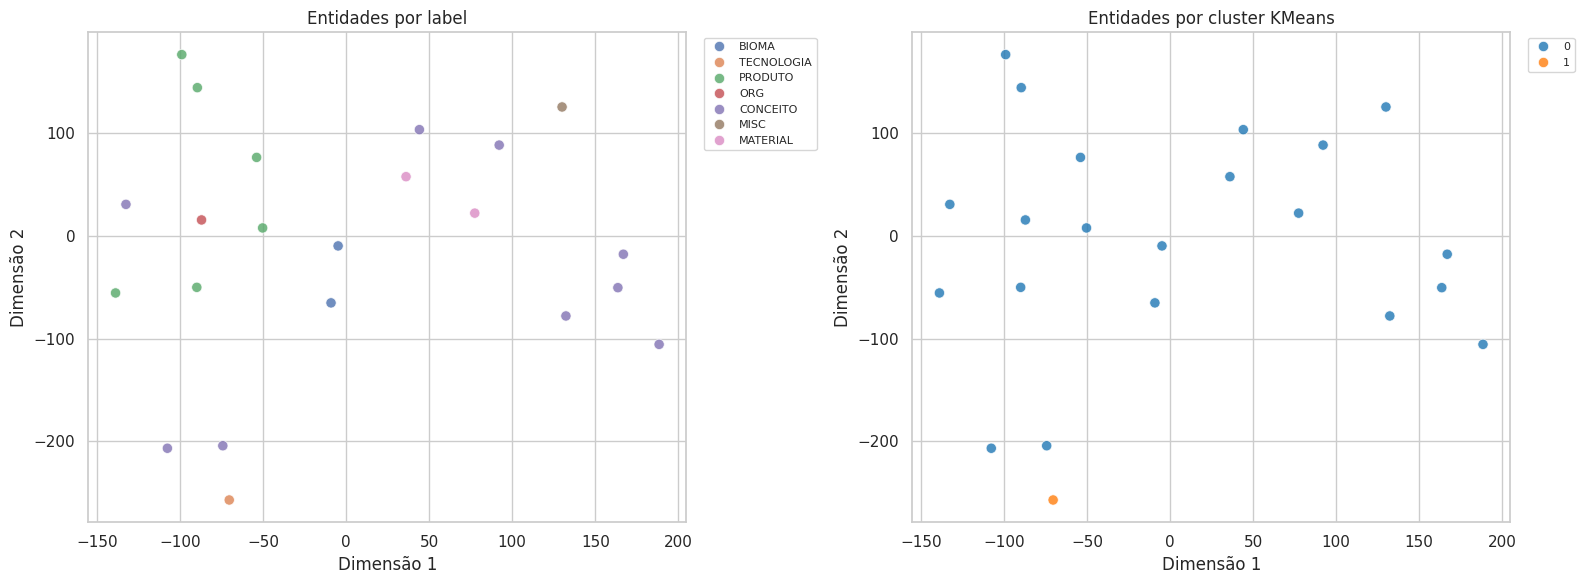

In [58]:
def run_tsne_safe(X_input: np.ndarray) -> tuple[np.ndarray, str]:
    n = X_input.shape[0]
    if n < 5:
        return safe_pca(X_input, 2), 'PCA fallback: poucos pontos'
    perplexity = min(30, max(2, int(math.sqrt(n))))
    perplexity = min(perplexity, n - 1)
    kwargs = {
        'n_components': 2,
        'perplexity': perplexity,
        'random_state': SEED,
        'init': 'pca',
        'learning_rate': 'auto',
    }
    signature = inspect.signature(TSNE)
    if 'max_iter' in signature.parameters:
        kwargs['max_iter'] = 1000
    else:
        kwargs['n_iter'] = 1000
    try:
        return TSNE(**kwargs).fit_transform(X_input), f't-SNE com perplexity={perplexity}'
    except Exception as exc:
        print(f'Aviso: t-SNE falhou. Usando PCA. Motivo: {exc}')
        return safe_pca(X_input, 2), 'PCA fallback após falha do t-SNE'

Z_2d, projection_used = run_tsne_safe(X_reduced if X_reduced.shape[0] else X)
print(f'Projeção usada: {projection_used}')

if len(unique_ents) > 0:
    unique_ents['x_2d'] = Z_2d[:, 0]
    unique_ents['y_2d'] = Z_2d[:, 1]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.scatterplot(data=unique_ents, x='x_2d', y='y_2d', hue='label', s=55, alpha=0.8, ax=axes[0])
    axes[0].set_title('Entidades por label')
    axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

    sns.scatterplot(data=unique_ents, x='x_2d', y='y_2d', hue='cluster_kmeans', palette='tab10', s=55, alpha=0.8, ax=axes[1])
    axes[1].set_title('Entidades por cluster KMeans')
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

    for ax in axes:
        ax.set_xlabel('Dimensão 1')
        ax.set_ylabel('Dimensão 2')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'projecao_2d_entidades.png', dpi=160)
    plt.show()
else:
    print('Sem entidades para visualização.')

## 13. Similaridade semântica com BERTimbau ou TF-IDF

In [59]:
def bert_embeddings(text_list: list[str], model_name: str = 'neuralmind/bert-base-portuguese-cased', max_items: int = 120):
    if not TRANSFORMERS_OK or len(text_list) == 0:
        return None, 'BERT indisponível'
    selected = text_list[:max_items]
    try:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModel.from_pretrained(model_name).to(device)
        model.eval()
        vectors = []
        batch_size = 16
        with torch.no_grad():
            for start in range(0, len(selected), batch_size):
                batch = selected[start:start + batch_size]
                enc = tokenizer(batch, padding=True, truncation=True, max_length=64, return_tensors='pt').to(device)
                out = model(**enc)
                token_embeddings = out.last_hidden_state
                mask = enc['attention_mask'].unsqueeze(-1).type_as(token_embeddings)
                pooled = (token_embeddings * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
                vectors.append(pooled.cpu().numpy())
        return normalize(np.vstack(vectors)), f'BERTimbau mean pooling ({len(selected)} itens)'
    except Exception as exc:
        print(f'Aviso: BERT falhou. Usando TF-IDF. Motivo: {exc}')
        return None, 'BERT falhou'

def tfidf_embeddings(text_list: list[str]):
    if len(text_list) == 0:
        return np.zeros((0, 1)), 'TF-IDF vazio'
    vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5))
    X_local = vectorizer.fit_transform(text_list)
    return normalize(X_local), 'TF-IDF char_wb'

semantic_texts = unique_ents['entidade'].astype(str).head(120).tolist() if len(unique_ents) else []
X_sem, semantic_source = bert_embeddings(semantic_texts)
if X_sem is None:
    X_sem, semantic_source = tfidf_embeddings(semantic_texts)

print(f'Fonte semântica: {semantic_source}')
print(f'Shape semântico: {X_sem.shape}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fonte semântica: BERTimbau mean pooling (22 itens)
Shape semântico: (22, 768)


In [60]:
def semantic_search(query: str, corpus: list[str], top_k: int = 5):
    if len(corpus) == 0:
        return pd.DataFrame(columns=['rank', 'consulta', 'resultado', 'score'])
    vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5)).fit(corpus + [query])
    X_corpus_local = normalize(vectorizer.transform(corpus))
    X_query = normalize(vectorizer.transform([query]))
    scores = cosine_similarity(X_query, X_corpus_local).ravel()
    top_idx = np.argsort(-scores)[:min(top_k, len(corpus))]
    return pd.DataFrame({
        'rank': range(1, len(top_idx) + 1),
        'consulta': query,
        'resultado': [corpus[i] for i in top_idx],
        'score': [float(scores[i]) for i in top_idx],
    })

queries = ['Cerrado', 'bioeconomia', 'inteligência artificial', 'cacau', 'Brasil']
semantic_results_df = pd.concat([semantic_search(q, semantic_texts, top_k=5) for q in queries], ignore_index=True) if semantic_texts else pd.DataFrame()
display(semantic_results_df)

,rank,consulta,resultado,score
0,1,Cerrado,Cerrado,1.000000
1,2,Cerrado,Plataforma de dados,0.026945
2,3,Cerrado,IoT,0.000000
3,4,Cerrado,Amazônia,0.000000
4,5,Cerrado,cacau,0.000000
5,1,bioeconomia,bioeconomia,1.000000
6,2,bioeconomia,fertilizante organomineral,0.049406
7,3,bioeconomia,Amazônia,0.025119
8,4,bioeconomia,inteligência artificial,0.014607
9,5,bioeconomia,cacau,0.000000


## 14. Análise de possíveis confusões de label

In [61]:
LABEL_KEYWORDS = {
    'LOC': ['brasil', 'região', 'território', 'estado', 'município', 'localizado', 'norte', 'sul'],
    'BIOMA': ['bioma', 'biodiversidade', 'floresta', 'savana', 'ecossistema', 'fauna', 'flora'],
    'CONCEITO': ['sustentabilidade', 'inovação', 'pesquisa', 'desenvolvimento', 'tecnologia', 'ods'],
    'PRODUTO': ['produto', 'alimento', 'ingrediente', 'nutricional', 'formulação', 'mercado'],
    'ORG': ['empresa', 'universidade', 'instituto', 'fundação', 'organização', 'laboratório'],
    'TECNOLOGIA': ['software', 'sensor', 'iot', 'dados', 'algoritmo', 'plataforma', 'sistema'],
    'MATERIAL': ['material', 'resíduo', 'amostra', 'composto', 'fertilizante', 'extrato'],
}

def score_context_by_label(context: str) -> dict:
    low = context.lower()
    return {label: sum(low.count(k) for k in keywords) for label, keywords in LABEL_KEYWORDS.items()}

confusion_rows = []
if not unique_ents.empty and not ner_dep_df.empty:
    contexts = ner_dep_df.groupby('entidade')['sentenca'].apply(lambda s: ' '.join(s.astype(str).head(20))).to_dict()
    for _, row in unique_ents.iterrows():
        ent = row['entidade']
        label = row['label']
        scores = score_context_by_label(contexts.get(ent, ''))
        best_label = max(scores, key=scores.get) if scores else label
        best_score = scores.get(best_label, 0)
        own_score = scores.get(label, 0)
        if best_score > own_score and best_score >= 2:
            confusion_rows.append({
                'entidade': ent,
                'label_atual': label,
                'label_sugerido_contexto': best_label,
                'score_atual': own_score,
                'score_sugerido': best_score,
                'freq': row.get('freq', 0),
                'exemplo_contexto': contexts.get(ent, '')[:300],
            })

confusion_df = pd.DataFrame(confusion_rows).sort_values(['score_sugerido', 'freq'], ascending=False) if confusion_rows else pd.DataFrame(columns=['entidade', 'label_atual', 'label_sugerido_contexto', 'score_atual', 'score_sugerido', 'freq', 'exemplo_contexto'])
print(f'Possíveis confusões encontradas: {len(confusion_df)}')
display(confusion_df.head(20))

Possíveis confusões encontradas: 3


,entidade,label_atual,label_sugerido_contexto,score_atual,score_sugerido,freq,exemplo_contexto
1,desenvolvimento sustentável,CONCEITO,BIOMA,2,3,1,"Pesquisa sobre biodiversidade, sociobiodiversidade e desenvolvimento sustentável no bioma Cerrado."
2,edge computing,CONCEITO,TECNOLOGIA,1,3,1,"Desenvolvimento de sensores IoT, edge computing e análise de dados para a indústria."
0,Plataforma de dados,MISC,TECNOLOGIA,0,2,1,Plataforma de dados para energia solar .


## 15. Exportação dos resultados

In [62]:
final_cols = ['entidade', 'label', 'label_original', 'freq', 'doc_freq', 'n_chars', 'n_tokens', 'dep_root', 'pos_root', 'head_text', 'cluster_kmeans', 'cluster_dbscan', 'x_2d', 'y_2d', 'sentenca']
existing_cols = [c for c in final_cols if c in unique_ents.columns]
final_table = unique_ents[existing_cols].copy() if len(unique_ents) else pd.DataFrame(columns=existing_cols)

label_summary = final_table.groupby('label', as_index=False).agg(entidades_unicas=('entidade', 'count'), frequencia_total=('freq', 'sum')).sort_values('entidades_unicas', ascending=False) if not final_table.empty else pd.DataFrame(columns=['label', 'entidades_unicas', 'frequencia_total'])
cluster_summary = final_table.groupby(['cluster_kmeans', 'label'], as_index=False).agg(entidades=('entidade', 'count')).sort_values(['cluster_kmeans', 'entidades'], ascending=[True, False]) if not final_table.empty and 'cluster_kmeans' in final_table.columns else pd.DataFrame(columns=['cluster_kmeans', 'label', 'entidades'])

final_table.to_csv(OUTPUT_DIR / 'entidades_clusters.csv', index=False, encoding='utf-8-sig')
label_summary.to_csv(OUTPUT_DIR / 'resumo_labels.csv', index=False, encoding='utf-8-sig')
cluster_summary.to_csv(OUTPUT_DIR / 'resumo_clusters.csv', index=False, encoding='utf-8-sig')
confusion_df.to_csv(OUTPUT_DIR / 'possiveis_confusoes_labels.csv', index=False, encoding='utf-8-sig')
df.to_csv(OUTPUT_DIR / 'corpus_limpo.csv', index=False, encoding='utf-8-sig')
semantic_results_df.to_csv(OUTPUT_DIR / 'busca_semantica.csv', index=False, encoding='utf-8-sig')

report = f"""# Relatório final - NLP com Deep Learning

Fonte dos dados: {dataset_source}
Registros processados: {len(df)}
Entidades extraídas: {len(ner_dep_df)}
Entidades únicas: {len(unique_ents)}
Modelo spaCy usado: {SPACY_MODEL_USED}
Fonte dos vetores para clusterização: {feature_source}
Fonte semântica: {semantic_source}
KMeans - K escolhido: {K_FINAL}
Possíveis confusões de label: {len(confusion_df)}

Arquivos exportados:
- entidades_clusters.csv
- resumo_labels.csv
- resumo_clusters.csv
- possiveis_confusoes_labels.csv
- corpus_limpo.csv
- busca_semantica.csv
"""

(OUTPUT_DIR / 'relatorio_final.md').write_text(report, encoding='utf-8')

print('Exportação concluída.')
print(f'Arquivos salvos em: {OUTPUT_DIR.resolve()}')
display(final_table.head(20))

Exportação concluída.
Arquivos salvos em: /kaggle/working


,entidade,label,label_original,freq,doc_freq,n_chars,n_tokens,dep_root,pos_root,head_text,cluster_kmeans,cluster_dbscan,x_2d,y_2d,sentenca
0,Cerrado,BIOMA,BIOMA,2,2,7.0,1.0,nmod,NOUN,Bioeconomia,0,0,-4.872717,-9.622578,Bioeconomia no Cerrado brasileiro .
1,Amazônia,BIOMA,BIOMA,2,1,8.0,1.0,nmod,PROPN,Conservação,0,-1,-9.143918,-65.154236,Conservação da Amazônia e cadeias produtivas .
2,IoT,TECNOLOGIA,TECNOLOGIA,2,1,3.0,1.0,flat:name,PROPN,Sistema,1,-1,-70.441948,-257.309357,Sistema IoT para monitoramento industrial .
3,baru,PRODUTO,PRODUTO,2,1,4.0,1.0,nmod,NOUN,base,0,-1,-138.923248,-55.500393,Produto funcional à base de baru e pequi .
4,cacau,PRODUTO,PRODUTO,2,1,5.0,1.0,nmod,NOUN,compostos,0,-1,-53.959568,76.651764,Estudo de compostos antioxidantes do cacau .
5,pequi,PRODUTO,PRODUTO,2,1,5.0,1.0,conj,NOUN,baru,0,-1,-89.989845,-50.026966,Produto funcional à base de baru e pequi .
6,sacarose,PRODUTO,PRODUTO,2,1,8.0,1.0,nmod,NOUN,substituto,0,-1,-89.652039,144.649857,Açúcar de frutas como substituto da sacarose .
7,BESS,ORG,ORG,1,1,4.0,1.0,conj,PROPN,geração,0,-1,-87.139839,15.684702,Solução baseada em IA para otimização de geração fotovoltaica e BESS.
8,ODS,CONCEITO,CONCEITO,1,1,3.0,1.0,conj,PROPN,Uso,0,-1,188.465973,-105.622032,"Uso de inteligência artificial, machine learning e ODS para inovação sustentável."
9,Plataforma de dados,MISC,MISC,1,1,19.0,3.0,ROOT,NOUN,Plataforma,0,1,130.017181,125.825378,Plataforma de dados para energia solar .
